# Machine Learning Part 2

We are using the general outline of the machine learning pipeline to structure our project:

1. Data cleaning and formatting
2. Exploratory data analysis
3. Feature engineering and selection\
__4. Compare several machine learning models on a performance metric__

The first notebook covered steps 1-3, and in this notebook
now we get to part 4


You have to;
1. rescale the data if necessary
2. use different models, SVM, Linear, Randomforest Regression
3. hyperparameter tuning
4. evaluate and compare models using the right metrics using plots

Your best model should reach at least the MSE of 10.5

Feel free to use any other model to compare base models with them.\
In fact finding and tuning any model (in Sklearn, or your own implementation) to perform better has `extra points`! (up to 20% of two parts)\
Just remember that you should be able to explain why your model performed better to claim the extra points! \
document your explanation along the answers with name `{Model_name}_stdName.pdf`

Good luck

### Imports 

We will use the standard data science and machine learning libraries in this project. 

In [8]:
# Pandas and numpy for data manipulation
import pandas as pd
import numpy as np

# No warnings about setting value on copy of slice
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', 60)

# Matplotlib for visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Set default font size
plt.rcParams['font.size'] = 24

from IPython.core.pylabtools import figsize

# Seaborn for visualization
import seaborn as sns
sns.set(font_scale = 2)

# Imputing missing values and scaling values
from sklearn.preprocessing import MinMaxScaler
# Imputer

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


### Read in Data

First let's read in the formatted data from the previous notebook. 

In [9]:
# Read in data into dataframes 
train_features = pd.read_csv('training_features.csv')
test_features = pd.read_csv('testing_features.csv')
train_labels = pd.read_csv('training_labels.csv')
test_labels = pd.read_csv('testing_labels.csv')

# Display sizes of data
print('Training Feature Size: ', train_features.shape)
print('Testing Feature Size:  ', test_features.shape)
print('Training Labels Size:  ', train_labels.shape)
print('Testing Labels Size:   ', test_labels.shape)

Training Feature Size:  (8032, 83)
Testing Feature Size:   (3443, 83)
Training Labels Size:   (8032, 1)
Testing Labels Size:    (3443, 1)


In [11]:
# شناسایی ستون‌های متنی
text_columns = train_features.select_dtypes(include=['object']).columns
print(f"Text columns: {text_columns}")

# حذف ستون‌های غیرضروری که برای پیش‌بینی مفید نیستند
columns_to_drop = [
    'Property Name', 'Parent Property Id', 'Parent Property Name', 'BBL - 10 digits',
    'NYC Borough, Block and Lot (BBL) self-reported', 'NYC Building Identification Number (BIN)',
    'Address 1 (self-reported)', 'Postal Code', 'Street Number', 'Street Name', 'Borough',
    'Primary Property Type - Self Selected', 'List of All Property Use Types at Property',
    'Largest Property Use Type', 'Metered Areas (Energy)', 'Release Date', 'Water Required?',
    'DOF Benchmarking Submission Status'
]

train_features = train_features.drop(columns=columns_to_drop)
test_features = test_features.drop(columns=columns_to_drop)

# تبدیل ویژگی‌های متنی به عددی
encoder = LabelEncoder()
for column in train_features.select_dtypes(include=['object']).columns:
    train_features[column] = encoder.fit_transform(train_features[column])
    test_features[column] = encoder.transform(test_features[column])

# مقیاس‌بندی داده‌ها
scaler = StandardScaler()

# مقیاس‌بندی داده‌های آموزشی
train_features_scaled = scaler.fit_transform(train_features)

# مقیاس‌بندی داده‌های تست
test_features_scaled = scaler.transform(test_features)

# نمایش چند نمونه از داده‌های مقیاس‌بندی شده
print(f"Scaled training features sample:\n{train_features_scaled[:5]}")
print(f"Scaled test features sample:\n{test_features_scaled[:5]}")


Text columns: Index(['Parent Property Id', 'Parent Property Name', 'BBL - 10 digits',
       'NYC Borough, Block and Lot (BBL) self-reported',
       'NYC Building Identification Number (BIN)', 'Address 1 (self-reported)',
       'Postal Code', 'Street Number', 'Street Name', 'Borough',
       'Primary Property Type - Self Selected',
       'List of All Property Use Types at Property',
       'Largest Property Use Type', 'Metered Areas (Energy)', 'Release Date',
       'Water Required?', 'DOF Benchmarking Submission Status'],
      dtype='object')
Scaled training features sample:
[[-1.59124641 -0.87115166 -0.21569641  0.01923095 -0.07231561  0.16443631
  -0.18865237 -0.87494706  0.71242843  0.00464126 -0.29821045 -0.20747546
   0.3746376  -0.20747546 -0.01932991 -0.01115874 -0.08747995 -0.01115874
  -0.01115874 -0.07421767 -0.02734173 -0.02953429 -0.04325534 -0.13463471
  -0.09240359 -0.01932991 -0.01115874 -0.06709882 -0.05119957 -0.01578183
   0.57044942 -0.01115874 -0.12975968 -0.36

SVM

In [12]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

# مدل SVM
svm_model = SVR(kernel='linear')
svm_model.fit(train_features_scaled, train_labels)
svm_predictions = svm_model.predict(test_features_scaled)

# محاسبه MSE
svm_mse = mean_squared_error(test_labels, svm_predictions)
print(f'SVM Model MSE: {svm_mse}')


c:\Users\niush\anaconda3\lib\site-packages\sklearn\utils\validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVM Model MSE: 411.98938114929115


Linear Regression

In [13]:
from sklearn.linear_model import LinearRegression

# مدل رگرسیون خطی
lr_model = LinearRegression()
lr_model.fit(train_features_scaled, train_labels)
lr_predictions = lr_model.predict(test_features_scaled)

# محاسبه MSE
lr_mse = mean_squared_error(test_labels, lr_predictions)
print(f'Linear Regression Model MSE: {lr_mse}')


Linear Regression Model MSE: 384.52678337597666


Random Forest

In [14]:
from sklearn.ensemble import RandomForestRegressor

# مدل جنگل تصادفی
rf_model = RandomForestRegressor()
rf_model.fit(train_features, train_labels)
rf_predictions = rf_model.predict(test_features)

# محاسبه MSE
rf_mse = mean_squared_error(test_labels, rf_predictions)
print(f'Random Forest Model MSE: {rf_mse}')


c:\Users\niush\anaconda3\lib\site-packages\sklearn\base.py:1152: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Random Forest Model MSE: 227.54731876270694


Comparing

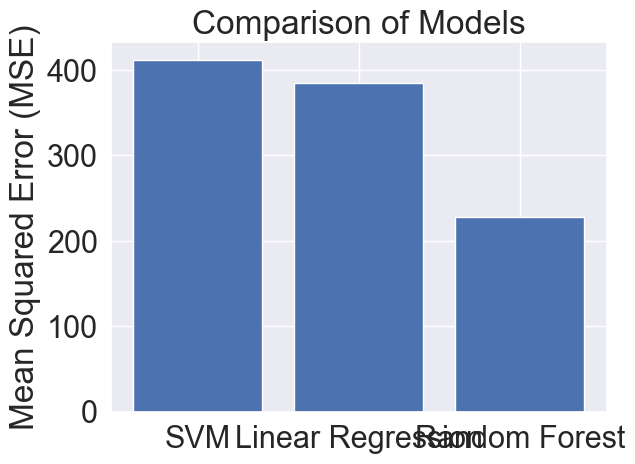

In [17]:
import matplotlib.pyplot as plt

# مقایسه مدل‌ها
models = ['SVM', 'Linear Regression', 'Random Forest']
mse_values = [svm_mse, lr_mse, rf_mse]

plt.bar(models, mse_values)
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Comparison of Models')
plt.show()
